In [1]:
from LCSS_new import *
import matplotlib.pyplot as plt
np.random.seed(42)

c:\Users\bik19\anaconda3\envs\GraphState\Lib\site-packages\cotengra\hyperoptimizers\hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(


In [2]:
class test:
    paulis_dict = {
        "_": np.eye(2),
        "X": np.array([[0,1],[1,0]], dtype=complex),
        "Y": np.array([[0,-1j],[1j,0]], dtype=complex),
        "Z": np.array([[1,0],[0,-1]], dtype=complex)
    }

    @staticmethod
    def pauli_to_mat(str):
        c = 1 if str[0]=='+' else -1
        l = [test.paulis_dict[s] for s in str[1:]]
        return c * reduce(lambda a,b: np.kron(a,b), l)

    @staticmethod
    def get_state(triple):
        n = len(triple.z0)
        k = len(triple.V)
        psi = np.zeros(2**n,dtype=complex)
        
        if(k == 0):
            term = sum(int(b) << (n - 1 - i) for i, b in enumerate(triple.z0 % 2))
            psi[term] = 1
            return psi
        
        for x in range(1 << k):       
            bits = [(x >> i) & 1 for i in range(k)] 
            coeff = (1j)**((triple.l @ bits) % 2) * (-1+0j)**(bits @ triple.Q @ bits)
            term = sum(int(b) << (n - 1 - i) for i, b in enumerate((bits @ triple.V + triple.z0) % 2))
            psi[term] = coeff/(2**(k/2))
        return psi

In [3]:
H = Pauli_Hamiltonian.TI_local_H(["XX","Z"],10)
HZ = H.Z_component()

H_mat = np.einsum('i,ijk',H.coeffs,[test.pauli_to_mat('+'+p) for p in H.paulis])
HZ_mat = np.einsum('i,ijk',HZ.coeffs,[test.pauli_to_mat('+'+p) for p in HZ.paulis])

In [4]:
N  = 100
states, energies = H.get_excited_states(N)
Z_excited_states, Z_energies  = HZ.get_excited_states(N)

In [5]:
extended_states = []
extended_energies = []
for i,s in enumerate(states):
    extended = full_extend_group(s)
    for e in extended:
        extended_states.append(e)
        extended_energies.append(energies[i])
        
extended_Z_states = []
extended_Z_energies = []
for i,s in enumerate(Z_excited_states):
    extended = extend_Z_group(s)
    for e in extended:
        extended_Z_states.append(e)
        extended_Z_energies.append(Z_energies[i])

In [6]:
### Do LCSS Analysis for the Stabilizer States ###
triples = [triple.get_triple(s) for s in extended_states]
statevectors = [test.get_state(t) for t in triples]


### Check 1: Stabilizers (good!) ###
err = []
for (s,g) in zip(statevectors, extended_states):
    for op in g:
        P = test.pauli_to_mat(op)
        err.append(np.linalg.norm(P @ s - s))
print(f"Stabilizer Error: {np.max(err)}")
print("-------------------------------------------")

### Check 2: Inner Products (good!) ###
N_states = len(extended_states)
O = np.eye(N_states,dtype=complex)
for i in range(0,N_states):
    for j in range(i+1,N_states):
        O[i,j] = triple.inner(triples[i], triples[j])
        O[j,i] = O[i,j].conjugate()
        
O_vec = np.zeros((N_states,N_states),dtype=complex)
for i in range(N_states):
    for j in range(N_states):
        O_vec[i,j] = statevectors[i].conjugate().T @ statevectors[j]

print(f"Overlap Error: {np.max(np.abs(O-O_vec))}")
print("-------------------------------------------")
### Check 3: Energ Matrix (good!) ###
new_states= [[t.apply_pauli(p) for p in H.paulis] for t in triples]

M = np.zeros((N_states,N_states),dtype=complex)
for i in range(N_states):
    M[i,i] = np.dot(H.coeffs,[pauli_expect(p, extended_states[i]) for p in H.paulis])
    for j in range(i+1,N_states):
        M[i,j] = np.dot(H.coeffs,[c*triple.inner(triples[i],t) for (c,t) in (new_states[j])])
        M[j,i] = M[i,j].conjugate() 
        
H_red = np.zeros((N_states,N_states),dtype=complex)
for i in range(N_states):
    for j in range(N_states):
        H_red[i,j] = statevectors[i].conjugate().T @ H_mat @ statevectors[j]
print(f"Energy Matrix Error: {np.max(np.abs(H_red-M))}")
print("-------------------------------------------")
### Check 4: Final LCSS (good!) ###
E,v = LCSS.basis_diagonalize(M,O)
final_state = np.sum([c * p for (c,p) in zip(v,statevectors)],axis=0)
print(f"LCSS Ground State Error: {final_state.conjugate().T @ H_mat @ final_state - E}")
print("-------------------------------------------")

Stabilizer Error: 0.0
-------------------------------------------
Overlap Error: 2.220446049250313e-16
-------------------------------------------
Energy Matrix Error: 3.552713678800501e-15
-------------------------------------------
LCSS Ground State Error: (4.440892098500626e-15+0j)
-------------------------------------------


In [7]:
instance = LCSS(H)
M,O = instance.run_LCSS(N)
E-LCSS.basis_diagonalize(M,O)[0]

------------extension--------------------
------------overlap--------------------
------------energies--------------------


np.float64(0.0)

In [8]:
Z_states = [get_Z_state(s) for s in extended_Z_states]
Z_statevectors = []
for x in Z_states:
    v = np.zeros(2**10)
    v[x]=1
    Z_statevectors.append(v)
    
### Check 1: Stabilizers (good!) ###
err = []
for (s,g) in zip(Z_statevectors, extended_Z_states):
    for op in g:
        P = test.pauli_to_mat(op)
        err.append(np.linalg.norm(P @ s - s))
print(f"Stabilizer Error: {np.max(err)}")
print("-------------------------------------------")

### Check 2: Inner Products (good!) ###
N_Z_states = len(extended_Z_states)
OZ = np.eye(N_Z_states,dtype=complex)
for i in range(0,N_Z_states):
    for j in range(i+1,N_Z_states):
        OZ[i,j] = int(Z_states[i] == Z_states[j])
        OZ[j,i] = int(Z_states[i] == Z_states[j])
        
O_vec = np.zeros((N_Z_states,N_Z_states),dtype=complex)
for i in range(N_Z_states):
    for j in range(N_Z_states):
        O_vec[i,j] = Z_statevectors[i].conjugate().T @ Z_statevectors[j]
print(f"Overlap Error: {np.max(np.abs(OZ-O_vec))}")
print("-------------------------------------------")

### Check 3: Energ Matrix (good!) ###

MZ = full_matrix(H, Z_states)   
H_red = H_mat[np.ix_(Z_states,Z_states)]
print(f"Energy Matrix Error: {np.max(np.abs(H_red-MZ))}")
print("-------------------------------------------")
E,v = LCSS.basis_diagonalize(MZ,OZ)
final_state = np.sum([c * p for (c,p) in zip(v,Z_statevectors)],axis=0)
print(f"LCSS Ground State Error: {final_state.conjugate().T @ H_mat @ final_state - E}")
print("-------------------------------------------")

Stabilizer Error: 0.0
-------------------------------------------
Overlap Error: 0.0
-------------------------------------------
Energy Matrix Error: 0.0
-------------------------------------------
LCSS Ground State Error: (3.552713678800501e-15+0j)
-------------------------------------------


In [9]:
MZ,OZ = instance.run_Z_LCSS(N)
E-LCSS.basis_diagonalize(MZ,OZ)[0]

np.float64(0.0)

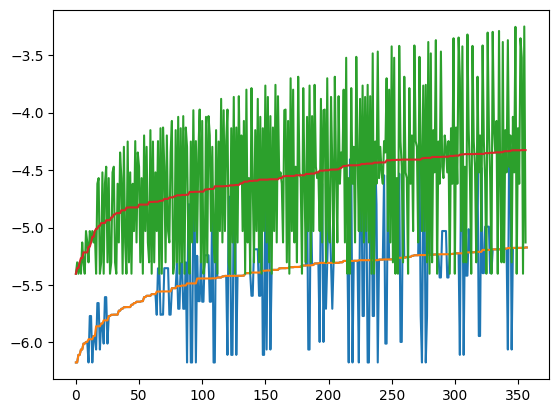

In [10]:
plt.plot(np.diag(M).real)
plt.plot(extended_energies)

plt.plot(np.diag(MZ).real)
plt.plot(extended_Z_energies)

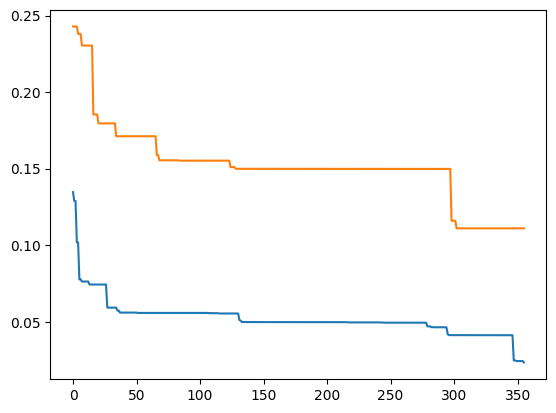

In [11]:
stabilizer_data = np.array([LCSS.basis_diagonalize(M[:i,:i],O[:i,:i])[0] for i in range(2,len(M))])
comp_data = np.array([LCSS.basis_diagonalize(MZ[:i,:i],OZ[:i,:i])[0] for i in range(2,len(M))])

g = run_dmrg(convert_to_mpos(H.paulis,H.coeffs),50)
plt.plot(abs(stabilizer_data - g)/abs(g))
plt.plot(abs(comp_data - g)/abs(g))

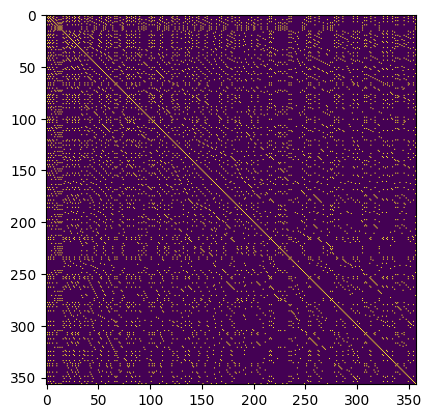

In [12]:
plt.imshow(abs(OZ))

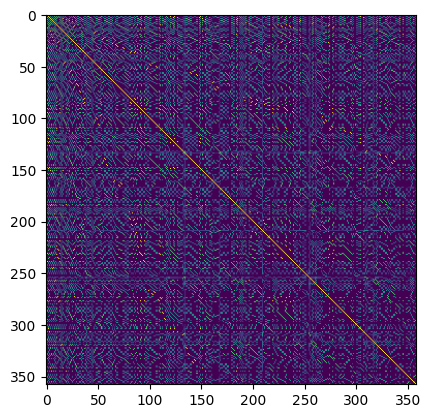

In [13]:
plt.imshow(abs(O))

(array([ 9.,  0.,  0., 53.,  0.,  0., 36.,  0.,  0.,  2.]),
 array([ 7. ,  7.3,  7.6,  7.9,  8.2,  8.5,  8.8,  9.1,  9.4,  9.7, 10. ]),
 <BarContainer object of 10 artists>)

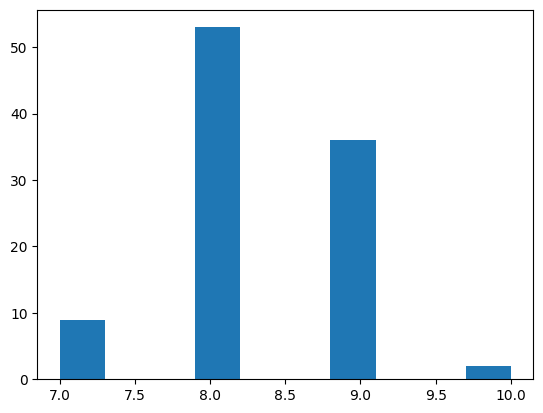

In [14]:
plt.hist([len(l) for l in states])

(array([ 1.,  0., 12.,  0.,  0., 40.,  0., 38.,  0.,  9.]),
 array([ 6. ,  6.4,  6.8,  7.2,  7.6,  8. ,  8.4,  8.8,  9.2,  9.6, 10. ]),
 <BarContainer object of 10 artists>)

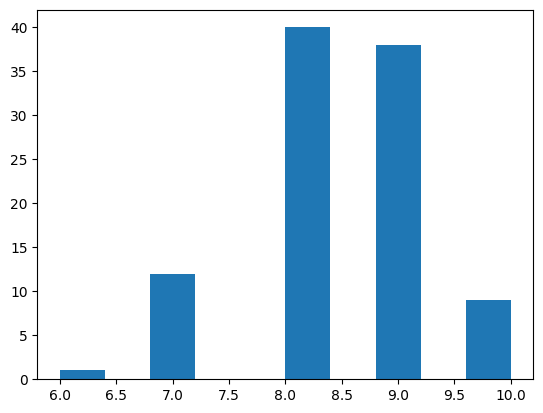

In [15]:
plt.hist([len(l) for l in Z_excited_states])

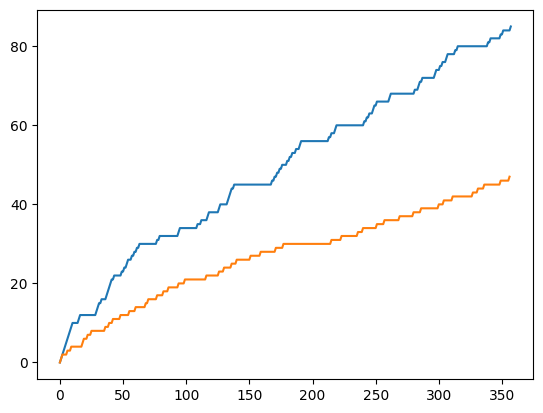

In [16]:
plt.plot([len(O[:i])-np.sum(np.isclose(np.linalg.eigvalsh(O[:i,:i]),0)) for i in range(len(O))])
plt.plot([len(OZ[:i])-np.sum(np.isclose(np.linalg.eigvalsh(OZ[:i,:i]),0)) for i in range(len(OZ))])

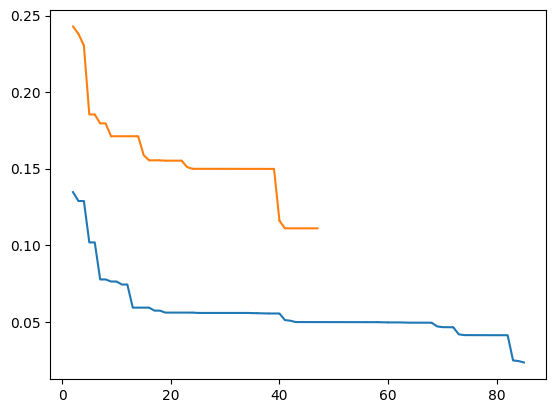

In [17]:
stabilizer_data = np.array([LCSS.basis_diagonalize(M[:i,:i],O[:i,:i])[0] for i in range(2,len(M))])
comp_data = np.array([LCSS.basis_diagonalize(MZ[:i,:i],OZ[:i,:i])[0] for i in range(2,len(MZ))])

stabilizer_data = abs((stabilizer_data-g)/g)
comp_data = abs((comp_data-g)/g)

plt.plot([len(O[:i])-np.sum(np.isclose(np.linalg.eigvalsh(O[:i,:i]),0)) for i in range(2,len(O))],stabilizer_data)
plt.plot([len(O[:i])-np.sum(np.isclose(np.linalg.eigvalsh(OZ[:i,:i]),0)) for i in range(2,len(OZ))],comp_data)